In [58]:
import numpy as np
import numpy.linalg as la

O3 = np.array([0,0,0,0])
def dveJed(Ah, A1h):
    jed1 = np.concatenate((O3, -A1h[2]*Ah, A1h[1]*Ah)) 
    jed2 = np.concatenate(( A1h[2]*Ah, O3, -A1h[0]*Ah))
    return np.array([jed1, jed2])

def matrica_kamere(pts, pts1):
    A = []
    for i in range(len(pts)):
        dve = dveJed(pts[i], pts1[i])
        A.append(dve[0])
        A.append(dve[1])
    np.array(A)
    U,S, Vh = la.svd(A)   
    matP = Vh[-1].reshape(3,4) 
    return matP/matP[-1,-1] 

In [59]:
def centar(T):
    C1 = np.linalg.det(np.delete(T, 0, 1))
    C2 = np.linalg.det(np.delete(T, 1, 1))
    C3 = np.linalg.det(np.delete(T, 2, 1))
    C4 = np.linalg.det(np.delete(T, 3, 1))
    C = np.array([C1, -C2, C3, -C4])*(-1/C4)
    return C

In [60]:
def matrica_kalibracije(T):
    t0 = np.delete(T, 3, 1)
    inverz = np.linalg.inv(t0)
    Q, R = np.linalg.qr(inverz)
    if(R[0,0] < 0):
        R = np.matmul(np.diag([-1,1,1]), R)
        q = np.matmul(Q ,np.diag([-1,1,1]))
    if(R[1,1] < 0):
        R = np.matmul(np.diag([1,-1,1]), R)
        q = np.matmul(Q ,np.diag([1,-1,1]))
    if(R[2,2] < 0):
        R = np.matmul(np.diag([1,1,-1]), R)
        q = np.matmul(Q ,np.diag([1,1,-1]))
    
    K = np.linalg.inv(R)
    return K/K[-1,-1]

In [61]:
def spoljasnja_matrica(T):
    t0 = np.delete(T, 3, 1)
    inverz = np.linalg.inv(t0)
    Q, R = np.linalg.qr(inverz)
    if(R[0,0] < 0):
        R = np.matmul(np.diag([-1,1,1]), R)
        q = np.matmul(Q ,np.diag([-1,1,1]))
    if(R[1,1] < 0):
        R = np.matmul(np.diag([1,-1,1]), R)
        q = np.matmul(Q ,np.diag([1,-1,1]))
    if(R[2,2] < 0):
        R = np.matmul(np.diag([1,1,-1]), R)
        q = np.matmul(Q ,np.diag([1,1,-1]))
    
    A = Q.T
    return A

In [62]:
M1 = np.array([692, 265, 1])
M2 = np.array([917, 368, 1])
M3 = np.array([679, 497, 1])
M4 = np.array([893, 616, 1])
M5 = np.array([688, 757, 1])
M6 = np.array([497, 613, 1])


im_dim = 1600


# 0 0 3
# 0 3 3
# 3 3 3
# 0 3 0
# 3 3 0
# 3 0 0

org1 = np.array([1, -1, -1])*(np.array([im_dim, 0, 0]) - np.array([M1, M2, M3, M4, M5, M6]))

M1p = np.array([0, 0, 3, 1])
M2p = np.array([0, 3, 3, 1])
M3p = np.array([3, 3, 3, 1])
M4p = np.array([0, 3, 0, 1])
M5p = np.array([3, 3, 0, 1])
M6p = np.array([3, 0, 0, 1])

img1 = np.array([M1p, M2p, M3p, M4p, M5p, M6p])
T1 = matrica_kamere(img1, org1)
print("Matrica kamere:\n")
print(T1)
print("--------------------------------------------------------------------------")
C = centar(T1)
print("Pozicija centra kamere:\n")
print(c)
print("--------------------------------------------------------------------------")
K = matrica_kalibracije(T1)
print("Matrica kalibracije kamere:\n")
print(K)
print("--------------------------------------------------------------------------")
A = spoljasnja_matrica(T1)
print("Spoljasnja matrica kamere:\n")
print(A)

Matrica kamere:

[[ 3.12828479e+01 -8.91821149e+01 -3.53289164e+01  9.01481929e+02]
 [ 1.72795741e+01  1.71673582e+01 -8.95261405e+01  5.00995136e+02]
 [-3.26265338e-02 -3.45322700e-02 -4.11945595e-02  1.00000000e+00]]
--------------------------------------------------------------------------
Pozicija centra kamere:

[8.91643965 9.60756109 9.15937907 1.        ]
--------------------------------------------------------------------------
Matrica kalibracije kamere:

[[ 1.33583712e+03 -1.47559478e+01  8.88822602e+02]
 [ 0.00000000e+00  1.32937566e+03  6.40216238e+02]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
--------------------------------------------------------------------------
Spoljasnja matrica kamere:

[[-0.72270301  0.69112365 -0.00696146]
 [-0.45659496 -0.46984825  0.75548902]
 [ 0.5188655   0.54917276  0.65512432]]


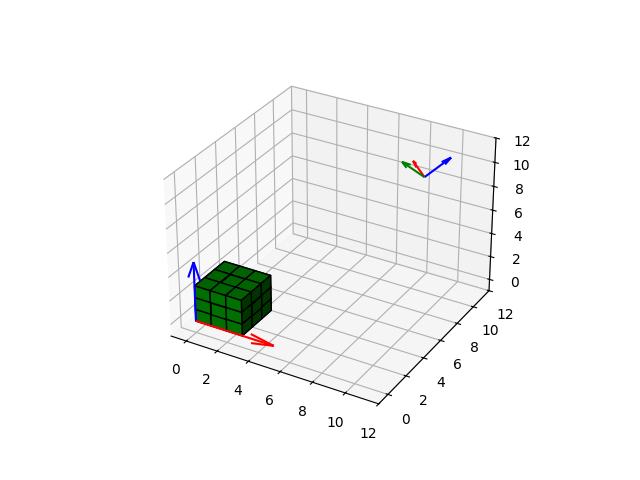

In [63]:
%matplotlib ipympl

import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure()

x, y, z = np.indices((15, 15, 15))

cube = (x < 3) & (y < 3) & (z < 3)
#camera = (x == round(C[0])) & (y == round(C[1])) & (z == round(C[2]))

voxelarray = cube

colors = np.empty(voxelarray.shape, dtype=object)
colors[cube] = 'green'
#colors[camera] = 'blue'

ax = fig.add_subplot(projection='3d')


ax.quiver(0, 0, 0, 5, 0, 0, colors="red")
ax.quiver(0, 0, 0, 0, 5, 0, colors="green")
ax.quiver(0, 0, 0, 0, 0, 5, colors="blue")

ax.voxels(voxelarray, facecolors=colors, edgecolor='k')

ax.quiver(C[0], C[1], C[2], 2*A[0][0], 2*A[0][1], 2*A[0][2], colors="red")
ax.quiver(C[0], C[1], C[2], 2*A[1][0], 2*A[1][1], 2*A[1][2], colors="green")
ax.quiver(C[0], C[1], C[2], 2*A[2][0], 2*A[2][1], 2*A[2][2], colors="blue")
# pomnozio sam sa 2 da bi se bolje videlo


ax.set_xlim3d(-1, 12)
ax.set_ylim3d(-1, 12)
ax.set_zlim3d(-1, 12)

plt.show()